In [1]:
# Compare with Ulaby 2014: code 11.2
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt

from misc.S2RTR import S2RTR

from VRT import VRT
from MORES import MORES
from init_tools import init_surface_from_mores, init_layer_from_mores
from postprocessing import Mueller2sigma0VH
from SmoothSurface import SmoothSurface
from AIEM import AIEM
from RayleighSphere import RayleighSphere
from RayleighSphereKsKa import RayleighSphereKsKa

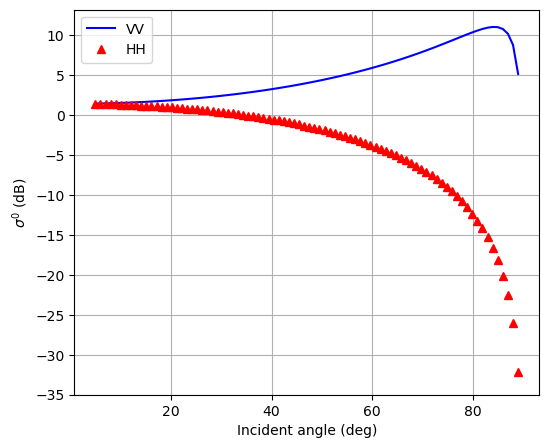

ks:0.0225, ka:0.1275, ke:0.15, ssa:0.15


In [7]:
freq = 10e9
ke = 0.15
a = 0.15
ks = a * ke
ka = ke - ks
epsr_bg = 100
d = 2
##################################################################
# surface = AIEM(epsilon_r=epsr_bg, kdel=0.3, kcor=1.0)
surface = SmoothSurface(epsilon_r=epsr_bg)
# layer = RayleighSphere(f=mores.freq, epsr_background=8.0, epsr_particle=3.2-3.2j, radius=0.05*3e8/mores.freq, fs=0.001, thickness=10)
layer = RayleighSphereKsKa(f=freq, epsr_background=epsr_bg, ks=ks, ka=ka, thickness=d)

vrt = VRT(surface, layer)
# run model and plot
theta_is = np.linspace(5, 89, 84)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
sigma0_HVs = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    # Mue = vrt.Mue_volume_nosurface((theta_i, 180, theta_i, 0))
    Mue = vrt.Mue_volume((theta_i, 180, theta_i, 0))
    sigma_VV, _, sigma_HV, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    sigma0_HHs[i] = sigma_HH
    sigma0_HVs[i] = sigma_HV

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
# sigma0_HV_dB = 10*np.log10(sigma0_HVs)
plt.figure(figsize=(6, 5))
plt.plot(theta_is, sigma0_VV_dB, 'b-', label='VV')
plt.plot(theta_is, sigma0_HH_dB, 'r^', label='HH')
# plt.plot(theta_is, sigma0_HV_dB, 'g--', label='HV')
# plt.ylim(-50, 10)
plt.xlabel('Incident angle (deg)')
plt.ylabel('$\sigma^0$ (dB)')
plt.legend()
plt.yticks(np.arange(-35, 15, 5))
plt.grid()
plt.show()
layer.print_params()

In [3]:
vrt.Mue_volume((theta_i, 180, theta_i, 0))

array([[2.57897355e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 4.88820820e-05, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 3.55057174e-03, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.55057174e-03]])